Things I need to change/check:

in $\texttt{constants.py}$:
- line 66: centre_str_band7 = 'J163135.656-240130.089'  
- line 110: PA_deg_sky_band7 = 139.5 
- line 121: StokesI_err_mJy_band7 = np.mean([0.0646, 0.0580, 0.0636, 0.056])
- line 122: StokesQ_err_mJy_band7 = np.mean([0.0317, 0.0311, 0.0398, 0.034]) # These values are from CASA 
- line 123: StokesU_err_mJy_band7 = np.mean([0.0247, 0.0249, 0.0255, 0.024]) # These values are from CASA 
- line 134: step_band7 = 7


in $\texttt{load_band7_data.py}$:
- line 68: StokesQ_err_mJy = np.full((ny, nx), constants.StokesQ_err_mJy_band7)
- line 80: StokesU_err_mJy = np.full((ny, nx), constants.StokesQ_err_mJy_band7)
- line 121: POLI_mJy = POLI_calc
- line 122: PA_rad = PA_calc_rad
- line 131: vector_len_pix_band7 = vector_len_pix_band4

In [1]:
%run constants.py

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND7_uncalibrated/load_band7_uncalibrated_data.py"

In [4]:
# %run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/CARTA FILES/BAND7_uncalibrated/load_carta_data_band7_uncalibrated.py"

# Find Peak POLI and get POLF

In [6]:
# Find index of max POLI_mJy, ignoring NaNs
y_max, x_max = np.unravel_index(np.nanargmax(POLI_mJy), POLI_mJy.shape)

# Get max POLI_mJy value
max_POLI = POLI_mJy[y_max, x_max]

# Get corresponding Stokes I value at same position
corresponding_I = StokesI_mJy[y_max, x_max]

# Compute calculated polarization fraction
calc_avg_POLF = max_POLI / corresponding_I 

# Get map POLF value
map_avg_POLF = POLF[y_max, x_max]

# Print results
print(rf'The maximum POLI value is {max_POLI:.3f}, and it happens at the index ({y_max}, {x_max})')
print(rf'At that index, the StokesI value is {corresponding_I:.3f}')
print(rf'At that index, the calculated POLF value is {calc_avg_POLF:.4f} or {calc_avg_POLF* 100:.4f}%')
print(rf'At that index, the map POLF value is {map_avg_POLF:.4f}')

The maximum POLI value is 1.668, and it happens at the index (268, 271)
At that index, the StokesI value is 157.993
At that index, the calculated POLF value is 0.0106 or 1.0556%
At that index, the map POLF value is 0.0106


In [7]:
# data_dict = {
#     "POLF_avg": [map_avg_POLF],
# }

# # Convert to DataFrame
# df = pd.DataFrame(data_dict)

# # Save to CSV
# df.to_csv(band7_data_folder_path + "constants_BAND7.csv", index=False)

# Stokes I and Polarized Intensity Plot with Vectors

In [31]:
max_index = np.argmax(StokesI_mJy)
y_max, x_max = np.unravel_index(max_index, StokesI_mJy.shape)

print(PA_rad[y_max, x_max])

nan


In [39]:
num_non_nan = np.count_nonzero(~np.isnan(PA_rad))
print(f"Number of non-NaN values: {num_non_nan}")

Number of non-NaN values: 12833


In [41]:
# Flatten and get sorted indices in descending order
sorted_flat_indices = np.argsort(StokesI_mJy, axis=None)[::-10]

# Get flat index of second max
second_max_index_flat = sorted_flat_indices[1]

# Convert flat index to (y, x)
y_2nd, x_2nd = np.unravel_index(second_max_index_flat, StokesI_mJy.shape)

# Access PA at second max location
print(PA_rad[y_2nd, x_2nd])

nan


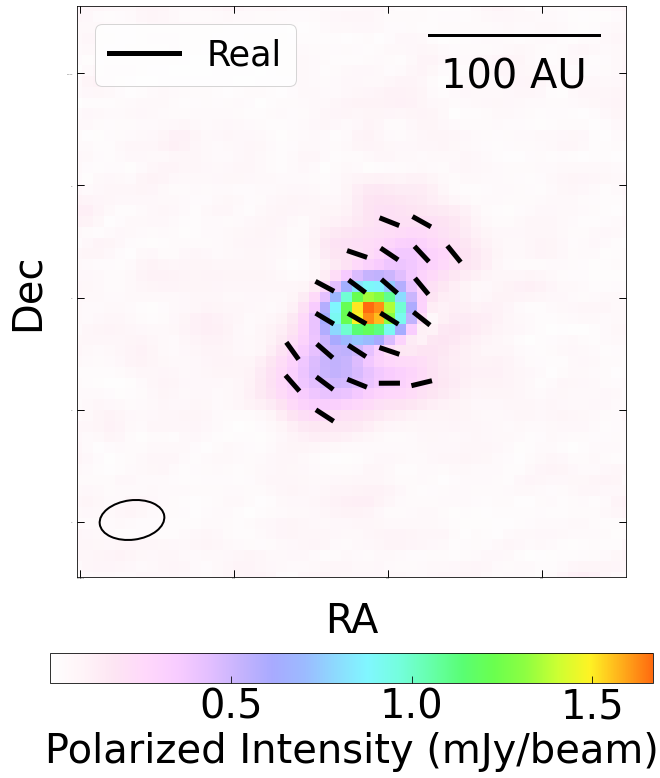

In [11]:
fig, ax = create_base_plot(StokesI_wcs, 
                           POLI_mJy, 'Polarized Intensity (mJy/beam)', 
                           soft_colormap_no_red, 
                           xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction,
                           cbar_fs = 40,
                           axis_label_fs = 40,
                           axis_num_fs = 21,
                           cbar_orientation = 'horizontal',
                           cbar_pad = 0.1,
                           cbar_shrink = 0.9,
                           fig_size_x = 12,
                           fig_size_y = 14,
                           text_fs = 40,
                           y_label = True, y_num = False,
                           x_label = True, x_num = False, 
                           full_axis_labels = False,
                           cbar_num_fs = 40,
                           line_y_frac = 0.05)


first_real = True
for row in vector_data_actual_cartesian:
    ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5, 
            label='Real' if first_real else None)
    first_real = False
    

ax.legend(fontsize = 35,
         loc = 'upper left')


plt.savefig(slideshow_image_folder_path + "IRS63_POLI_BAND7_slides.jpeg", 
            dpi=300, 
            bbox_inches='tight')  

# Slices Along Major and Minor Axes

In [12]:
# major_data_StokesI, major_offset_arcsec_StokesI, minor_data_StokesI, minor_offset_arcsec_StokesI, slices_points = run_slices(StokesI_mJy, 
#                                                                                                                              StokesI_header,
#                                                                                                                              StokesI_wcs,
#                                                                                                                              carta_major_data_mJy_StokesI, 
#                                                                                                                              carta_minor_data_mJy_StokesI,
#                                                                                                                              carta_minor_offset_StokesI,
#                                                                                                                              carta_major_offset_StokesI,
#                                                                                                                              band = 7,
#                                                                                                                              print_statement = False)

In [13]:
# major_data_POLI, major_offset_arcsec_POLI, minor_data_POLI, minor_offset_arcsec_POLI, _ = run_slices(POLI_mJy, 
#                                                                                                      StokesI_header,
#                                                                                                      StokesI_wcs, 
#                                                                                                      carta_major_data_mJy_POLI,
#                                                                                                      carta_minor_data_mJy_POLI,
#                                                                                                      carta_minor_offset_POLI,
#                                                                                                      carta_major_offset_POLI,
#                                                                                                      band = 7,
#                                                                                                      print_statement = False)

In [14]:
# major_data_POLF, major_offset_arcsec_POLF, minor_data_POLF, minor_offset_arcsec_POLF, _ = run_slices(POLF, 
#                                                                                                      StokesI_header,
#                                                                                                      StokesI_wcs, 
#                                                                                                      carta_major_data_POLF,
#                                                                                                      carta_minor_data_POLF,
#                                                                                                      carta_minor_offset_POLF,
#                                                                                                      carta_major_offset_POLF,
#                                                                                                      band = 7,
#                                                                                                      print_statement = False)

In [15]:
# data_dict = {
#     "StokesI_major"         : major_data_StokesI,
#     "StokesI_offset_major": major_offset_arcsec_StokesI,
#     "StokesI_minor"         : minor_data_StokesI,
#     "StokesI_offset_minor": minor_offset_arcsec_StokesI
# }

# # Convert to DataFrame
# df = pd.DataFrame(data_dict)

# # Save to CSV
# df.to_csv(band7_carta_folder_path + "IRS63_my_slice_StokesI_BAND7.csv", index=False)

In [16]:
# data_dict = {
#     "POLI_major"         : major_data_POLI,
#     "POLI_offset_major": major_offset_arcsec_POLI,
#     "POLI_minor"         : minor_data_POLI,
#     "POLI_offset_minor": minor_offset_arcsec_POLI
# }

# # Convert to DataFrame
# df = pd.DataFrame(data_dict)

# # Save to CSV
# df.to_csv(band7_carta_folder_path + "IRS63_my_slice_POLI_BAND7.csv", index=False)

In [17]:
# data_dict = {
#     "POLF_major"         : major_data_POLF,
#     "POLF_offset_major"  : major_offset_arcsec_POLF,
#     "POLF_minor"         : minor_data_POLF,
#     "POLF_offset_minor"  : minor_offset_arcsec_POLF
# }

# # Convert to DataFrame
# df = pd.DataFrame(data_dict)

# # Save to CSV
# df.to_csv(band7_carta_folder_path + "IRS63_my_slice_POLF_BAND7.csv", index=False)

In [18]:
# major_x, major_y, minor_x, minor_y = slices_points

In [19]:
# fig, ax = create_base_plot(StokesI_wcs, POLI_mJy, 'Polarized Intensity (mJy/beam)', soft_colormap_v2, 
#                            xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
#                            BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
#                            max_length_pix, reference_fraction)

# ax.scatter(major_x, 
#            major_y, 
#            label = 'Major Axis Slice',
#            color  = 'blue')

# ax.scatter(minor_x, 
#            minor_y, 
#            label = 'Minor Axis Slice',
#            color = 'red')

# ax.legend(fontsize = legend_text_fs, loc = 'upper left')

In [20]:
# fig, ax = create_base_plot(StokesI_wcs, 
#                            POLI_mJy, 'Polarized Intensity (mJy/beam)', 
#                            soft_colormap_no_red, 
#                            xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
#                            BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
#                            max_length_pix, reference_fraction,
#                            cbar_fs = 23,
#                            axis_label_fs = 25,
#                            axis_num_fs = 21,
#                            cbar_orientation = 'horizontal',
#                            cbar_pad = 0.1,
#                            cbar_shrink = 0.9,
#                            fig_size_x = 12,
#                            fig_size_y = 14)


# ax.scatter(major_x, 
#            major_y, 
#            label = 'Major',
#            color  = 'blue')

# ax.scatter(minor_x, 
#            minor_y, 
#            label = 'Minor',
#            color = 'red')

# ax.legend(fontsize = 30, loc = 'upper left')


# plt.savefig(slideshow_image_folder_path + "IRS63_minor_major_slices_BAND7_slides.jpeg", 
#             dpi=300, 
#             bbox_inches='tight')  


In [21]:
# ax = plot_slices_along_axes(
#     major_data_StokesI,
#     minor_data_StokesI,
#     carta_major_data_mJy_StokesI,
#     carta_minor_data_mJy_StokesI,
#     major_offset_arcsec_StokesI,
#     minor_offset_arcsec_StokesI,
#     carta_major_offset_StokesI,
#     carta_minor_offset_StokesI,
#     BMAJ_deg, BMIN_deg, 
#     y_label="Stokes I (mJy/beam)",
#     type_of_plot="Line",  # or "Scatter",
#     cb_friendly = False,
#     vline = True,
#     fit_slices = True
# )

# plt.savefig(image_folder_path + "IRS63_StokesI_slice_BAND7.pdf", 
#             dpi=300, 
#             bbox_inches='tight')


In [22]:
# ax = plot_slices_along_axes(
#     major_data_POLI,
#     minor_data_POLI,
#     carta_major_data_mJy_POLI,
#     carta_minor_data_mJy_POLI,
#     major_offset_arcsec_POLI,
#     minor_offset_arcsec_POLI,
#     carta_major_offset_POLI,
#     carta_minor_offset_POLI,
#     BMAJ_deg, BMIN_deg, 
#     y_label="Polarized Intensity (mJy/beam)",
#     type_of_plot="Line",  # "Line" or "Scatter",
#     cb_friendly = False,
#     vline = True,
#     fit_slices = True
# )

# plt.savefig(image_folder_path + "IRS63_POLI_slice_BAND7.pdf", 
#             dpi=300, 
#             bbox_inches='tight')    


In [23]:
# ax = plot_slices_along_axes(
#     major_data_POLF,
#     minor_data_POLF,
#     carta_major_data_POLF,
#     carta_minor_data_POLF,
#     major_offset_arcsec_POLF,
#     minor_offset_arcsec_POLF,
#     carta_major_offset_POLF,
#     carta_minor_offset_POLF,
#     BMAJ_deg, BMIN_deg, 
#     y_label="Polarized Fraction",
#     type_of_plot="Line",  # "Line" or "Scatter",
#     cb_friendly = False,
#     vline = True,
#     fit_slices = True
# )

# plt.savefig(image_folder_path + "IRS63_POLF_slice_BAND7.pdf", 
#             dpi=300, 
#             bbox_inches='tight') 


# Fitting the slices


$I(r) \propto r^\alpha$

Take log of both sides:
$\log_{10}(I(r))=\alpha \log_{10}(r)+C$

We need to comvert the data from mJy/beam to mJy/arcsec$^2$ (or radians will also work).

We can calculate the beam area with the equation:
$1.113 \cdot BMAJ \cdot BMIN$,
where $BMAJ$ and $BMIN$

# Ratio Models

In [24]:
vector_data_plotting_grid, vector_data_list_100U_to_100A, testing_vector_angles = ratio_model_band47(StokesQ_grid_100Uniform, StokesU_grid_100Uniform,
                                                                                           StokesQ_grid_100Azimuthal, StokesU_grid_100Azimuthal,
                                                                                           ny, nx,
                                                                                           vector_length_pix_const,
                                                                                           POLI_mJy, POLI_err_mJy, 
                                                                                           PA_err_deg,
                                                                                           'band 7'
                                                                                           # step = 10,
                                                                                           )

/opt/anaconda3/lib/python3.9/site-packages/IPython/core/events.py:89: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.9/site-packages/IPython/core/events.py:89: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)


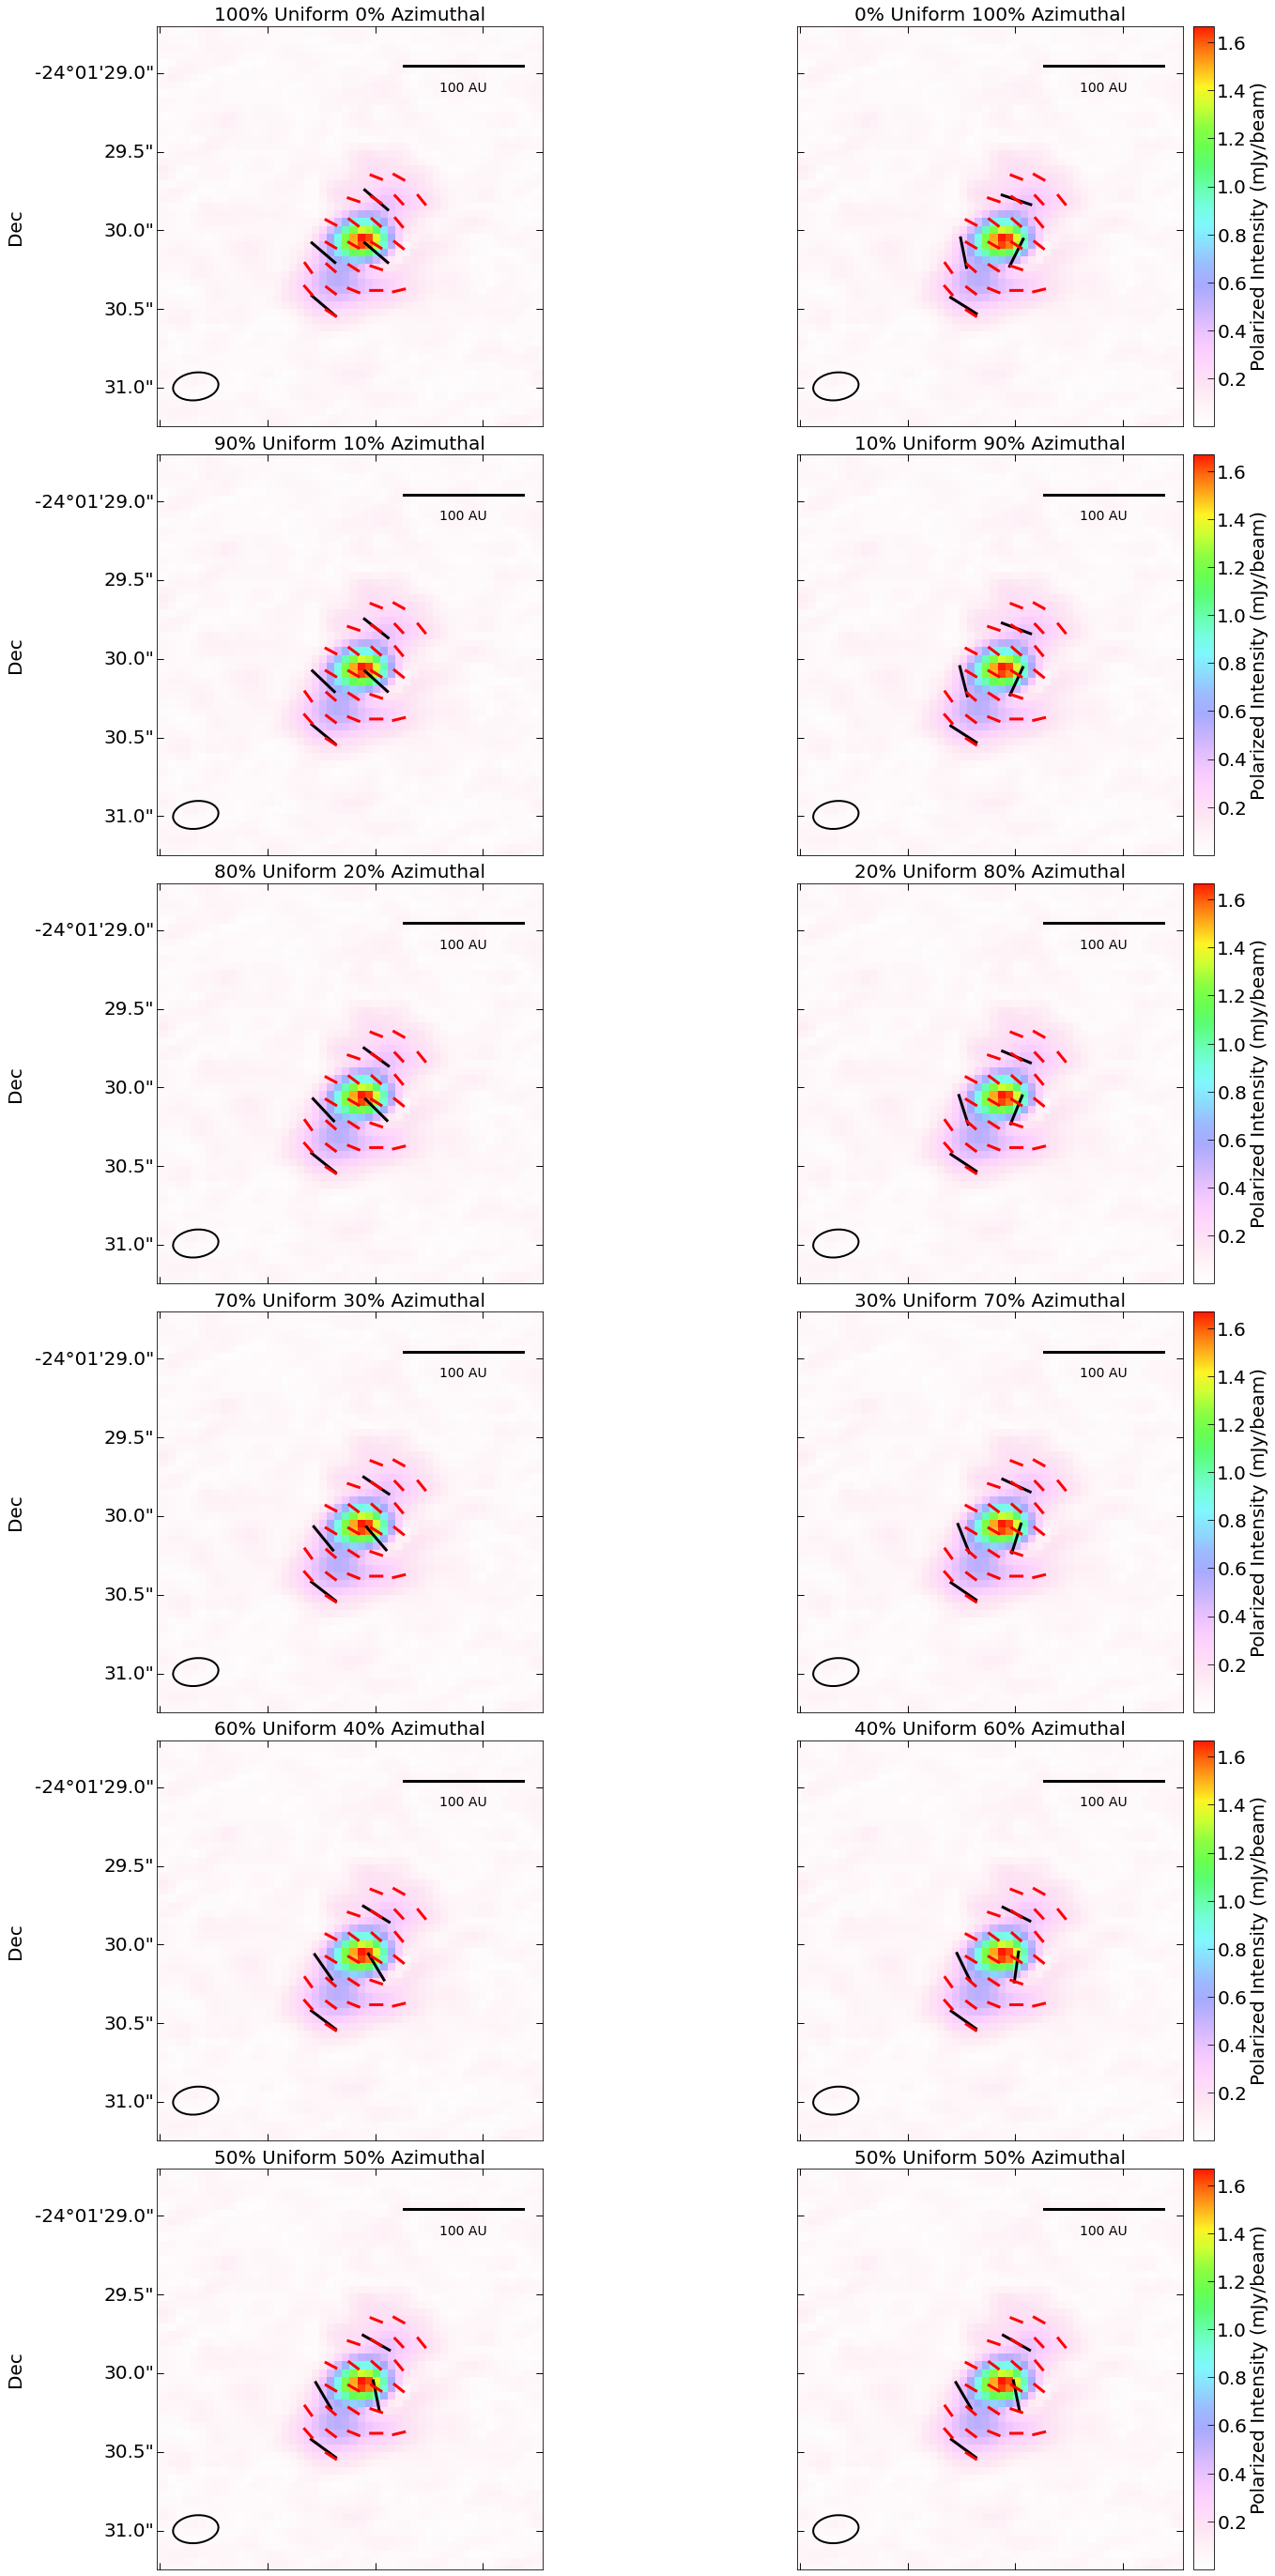

In [25]:
ax = plot_ratio_grid(POLI_mJy,
                    StokesI_wcs, soft_colormap_v2, 
                    xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                    BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                    max_length_pix, reference_fraction,
                    vector_data_actual_cartesian, vector_data_plotting_grid)

## Find the best one

In [26]:
min_index = find_best_fit_ratio_model(vector_angle_actual_sky, testing_vector_angles)

ValueError: operands could not be broadcast together with shapes (466,) (2454,) 

In [ ]:
fig, ax = create_base_plot(StokesI_wcs, POLI_mJy, 'Polarized Intensity (mJy/beam)' , 
                           soft_colormap_no_red, 
                           xmin, xmax , ymin, ymax, reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction)

# Add vector plots (Best Model: black)
for i, row in enumerate(vector_data_list_100U_to_100A[min_index]):
    if i == 0:
        ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5, label='Best Model')
    else:
        ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5)

# Plot actual vector data (Real: red)
for i, row in enumerate(vector_data_actual_cartesian):
    if i == 0:
        ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw=5, label='Real')
    else:
        ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw=5)

# Show legend
ax.legend(fontsize=legend_title_fs, loc = 'best')



plt.savefig(writeup_image_folder_path + "IRS63_best_ratio_BAND7.pdf", 
            dpi=300, 
            bbox_inches='tight')   


In [ ]:
fig, ax = create_base_plot(StokesI_wcs, 
                           POLI_mJy, 'Polarized Intensity (mJy/beam)', 
                           soft_colormap_no_red, 
                           xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction,
                           cbar_fs = 40,
                           axis_label_fs = 40,
                           axis_num_fs = 21,
                           cbar_orientation = 'horizontal',
                           cbar_pad = 0.1,
                           cbar_shrink = 0.9,
                           fig_size_x = 12,
                           fig_size_y = 14,
                           text_fs = 40,
                           y_label = True, y_num = False,
                           x_label = True, x_num = False, 
                           full_axis_labels = False,
                           cbar_num_fs = 40,
                           line_y_frac = 0.05)


first_real = True
for row in vector_data_actual_cartesian:
    ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5, 
            label='Real' if first_real else None)
    first_real = False
    
    
# Add vector plots (Best Model: black)
for i, row in enumerate(vector_data_list_100U_to_100A[min_index]):
    if i == 0:
        ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw=5, label='Model')
    else:
        ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw=5)

ax.legend(fontsize = 35,
         loc = 'upper left')


plt.savefig(slideshow_image_folder_path + "IRS63_best_ratio_BAND7_slides.jpeg", 
            dpi=300, 
            bbox_inches='tight')  

# Gaussian Model 

In [ ]:
phi_values = [2, 3, 4, 5, 6, 7]


BMAJ_values_pix =  np.array([10, 20, 30, 40, 50]) # + np.array(BMAJ_pix, dtype=int)
BMIN_values_pix =  np.array([10, 20, 30, 40, 50]) # + np.array(BMIN_pix, dtype=int)

# Print results
print(f'The BMAJ pix values we will test are: {BMAJ_values_pix}')
print(f'The BMIN pix values we will test are: {BMIN_values_pix}')

In [ ]:
gaussian_values, gaussian_results, vector_data_gaussian_best, GaussianUniformRatios_best = run_gaussian_model_band47(major_angle_rad_cartesian_band4, phi_values, 
                                                                                                                     BMAJ_values_pix, BMIN_values_pix, 
                                                                                                                     RA_centre_pix, Dec_centre_pix, 
                                                                                                                     StokesQ_grid_100Uniform, StokesU_grid_100Uniform,
                                                                                                                     StokesQ_grid_100Azimuthal, StokesU_grid_100Azimuthal,
                                                                                                                     vector_angle_actual_sky,
                                                                                                                     ny, nx, 
                                                                                                                     POLI_mJy, POLI_err_mJy, 
                                                                                                                     PA_err_deg,
                                                                                                                     'band 7',
                                                                                                                     print_statements = True)

In [ ]:
fig, ax = create_base_plot(StokesI_wcs, 
                           POLI_mJy, 'Polarized Intensity (mJy/beam)', 
                           soft_colormap_no_red, 
                           xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction)

first_real = True
for row in vector_data_actual_cartesian:
    ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5, 
            label='Real' if first_real else None)
    first_real = False
    
    
# Add vector plots, ensuring the label appears only once
first_best_model = True
for row in vector_data_gaussian_best:
    ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw=5, 
            label='Best Gaussian Model' if first_best_model else None)
    first_best_model = False

ax.legend(fontsize = legend_text_fs,
         loc = 'upper left')


plt.savefig(writeup_image_folder_path + "IRS63_best_gaussian_BAND7.pdf", 
            dpi=300, 
            bbox_inches='tight')  

In [ ]:
POLI_mJy.shape

In [ ]:
fig, ax = create_base_plot(StokesI_wcs, 
                           POLI_mJy, 'Polarized Intensity (mJy/beam)', 
                           soft_colormap_no_red, 
                           xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction,
                           cbar_fs = 23,
                           axis_label_fs = 25,
                           axis_num_fs = 21,
                           cbar_orientation = 'horizontal',
                           cbar_pad = 0.1,
                           cbar_shrink = 0.9,
                           fig_size_x = 12,
                           fig_size_y = 14)


first_real = True
for row in vector_data_actual_cartesian:
    ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw=5, 
            label='Real' if first_real else None)
    first_real = False
    
    
# Add vector plots, ensuring the label appears only once
first_best_model = True
for row in vector_data_gaussian_best:
    ax.plot([row[0], row[1]], [row[2], row[3]], color='red', lw=5, 
            label='Model' if first_best_model else None)
    first_best_model = False

ax.legend(fontsize = 25,
         loc = 'upper left')


plt.savefig(slideshow_image_folder_path + "IRS63_best_gaussian_BAND7_slides.jpeg", 
            dpi=300, 
            bbox_inches='tight')  

## Average POLF when Scattering

In [ ]:
POLF_average = get_average_POLF_where_scattered(GaussianUniformRatios_best, POLF, tolerance = 0.03)
print(rf'The average POLF where self-scattering is: {POLF_average:.3f}')

In [ ]:
POLF_average * 100

## Analyze Gaussian

In [ ]:
analyze_gaussian_averages_vs_chi2(gaussian_values, phi_values, BMAJ_values_pix, BMIN_values_pix)

In [ ]:
plot_2d_contours_for_gaussian(gaussian_values, phi_values, BMAJ_values_pix, BMIN_values_pix, 'phi', soft_colormap_v2)

In [ ]:
plot_2d_contours_for_gaussian(gaussian_values, phi_values, BMAJ_values_pix, BMIN_values_pix, 'BMIN', soft_colormap_v2)

In [ ]:
plot_2d_contours_for_gaussian(gaussian_values, phi_values, BMAJ_values_pix, BMIN_values_pix, 'BMAJ', soft_colormap_v2)

##### 